# Classify stress-strain images as rubber vs thermoplastic

In [9]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

image_size = 180
batch_size = 99
CLASS_NAMES = ["rubbers", "thermoplastics"]  # index 0 / 1


Using device: cuda


# Load the images

In [10]:
def load_npz(path: str) -> torch.Tensor:
    arr = np.load(path)["images"]                       # (N, H, W) uint8
    t = torch.from_numpy(arr.astype(np.float32) / 255.0)  # [0, 1] float32
    return t.unsqueeze(1)                               # (N, 1, H, W)


rubbers = load_npz("rubbers.npz")
thermoplastics = load_npz("thermoplastics.npz")
print(f"rubbers: {rubbers.shape}")
print(f"thermoplastics: {thermoplastics.shape}")

X = torch.cat([rubbers, thermoplastics], dim=0)
y = torch.cat([
    torch.zeros(len(rubbers), dtype=torch.long),
    torch.ones(len(thermoplastics), dtype=torch.long),
])
# resize to the model's fixed input size
X = F.interpolate(X, size=(image_size, image_size), mode="bilinear", align_corners=False)
print(f"dataset: {X.shape} (N, 1, H, W)")

dataset = TensorDataset(X, y)
print(f"total images: {len(dataset)}")

train_ds, val_ds = random_split(
    dataset,
    [int(0.75 * len(dataset)), len(dataset) - int(0.75 * len(dataset))],
    generator=torch.Generator().manual_seed(123),
)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

rubbers: torch.Size([117, 1, 400, 400])
thermoplastics: torch.Size([490, 1, 400, 400])
dataset: torch.Size([607, 1, 180, 180]) (N, 1, H, W)
total images: 607


# Plot representative images

> saved example_rubbers.png and example_thermoplastics.png


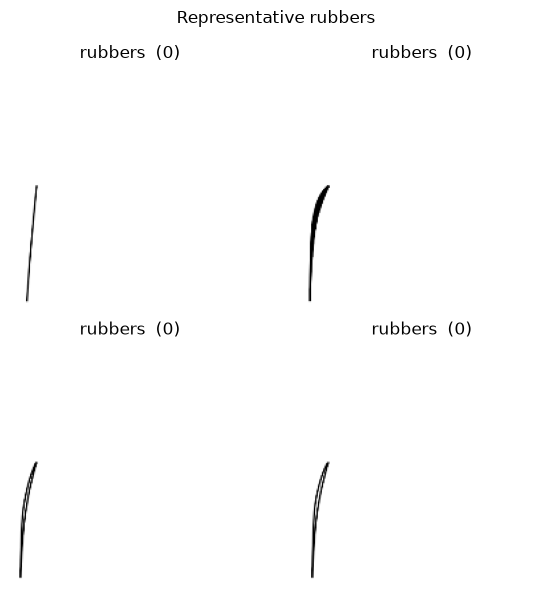

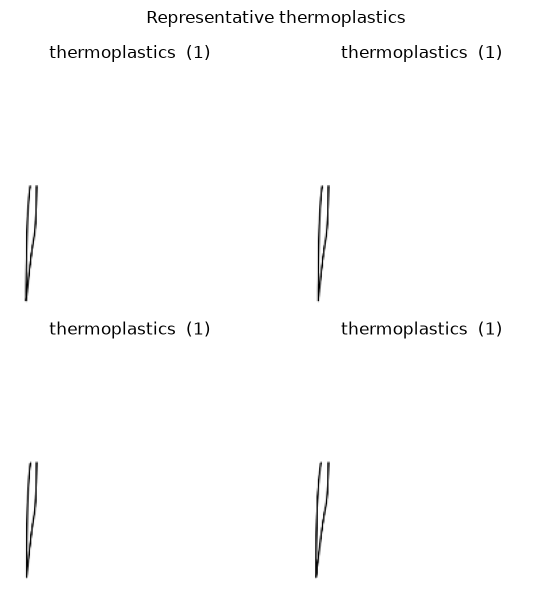

In [11]:
def plot_class_grid(class_idx: int, fname: str):
    idxs = [i for i in range(len(y)) if y[i] == class_idx][:4]
    fig, axes = plt.subplots(2, 2, figsize=(6, 6))
    for ax, i in zip(axes.ravel(), idxs):
        ax.imshow(X[i].squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{CLASS_NAMES[class_idx]}  ({class_idx})")
        ax.axis("off")
    fig.suptitle(f"Representative {CLASS_NAMES[class_idx]}")
    fig.tight_layout()

plot_class_grid(0, "example_rubbers.png")
plot_class_grid(1, "example_thermoplastics.png")
print("> saved example_rubbers.png and example_thermoplastics.png")

# Build the model

In [12]:
class PolymerNet(nn.Module):
    """Same conv stack as before, but 1 input channel (grayscale)."""

    def __init__(self, image_size=180):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
        )
        with torch.no_grad():
            flat_dim = self.features(torch.zeros(1, 1, image_size, image_size)).flatten(1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = PolymerNet(image_size=image_size).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            correct += ((logits > 0) == labels.bool()).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

# Train the model

In [13]:
print("\n> Training")
history = {"epoch": [], "train_loss": [], "val_loss": []}
for epoch in range(1, 26):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"epoch {epoch}/25 - loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

torch.save(model.state_dict(), "polymer_model.pt")
print(f"\nFinal validation accuracy: {val_acc:.4f}")


> Training
epoch 1/25 - loss: 0.6795 - acc: 0.8989 - val_loss: 0.6815 - val_acc: 0.8224
epoch 2/25 - loss: 0.6097 - acc: 0.8088 - val_loss: 0.6139 - val_acc: 0.8026
epoch 3/25 - loss: 0.6100 - acc: 0.8198 - val_loss: 0.6148 - val_acc: 0.8026
epoch 4/25 - loss: 0.6001 - acc: 0.8967 - val_loss: 0.6073 - val_acc: 0.8618
epoch 5/25 - loss: 0.5763 - acc: 0.8967 - val_loss: 0.5848 - val_acc: 0.8618
epoch 6/25 - loss: 0.5476 - acc: 0.9648 - val_loss: 0.5586 - val_acc: 0.9145
epoch 7/25 - loss: 0.5066 - acc: 0.9846 - val_loss: 0.5222 - val_acc: 0.9605
epoch 8/25 - loss: 0.4347 - acc: 0.9890 - val_loss: 0.4574 - val_acc: 0.9539
epoch 9/25 - loss: 0.3219 - acc: 0.9890 - val_loss: 0.3507 - val_acc: 0.9539
epoch 10/25 - loss: 0.2895 - acc: 0.9868 - val_loss: 0.3238 - val_acc: 0.9474
epoch 11/25 - loss: 0.1939 - acc: 0.9846 - val_loss: 0.2581 - val_acc: 0.9276
epoch 12/25 - loss: 0.1273 - acc: 0.9890 - val_loss: 0.2040 - val_acc: 0.9342
epoch 13/25 - loss: 0.0607 - acc: 0.9912 - val_loss: 0.1263 -

# Plot training results

> saved loss_curve.png


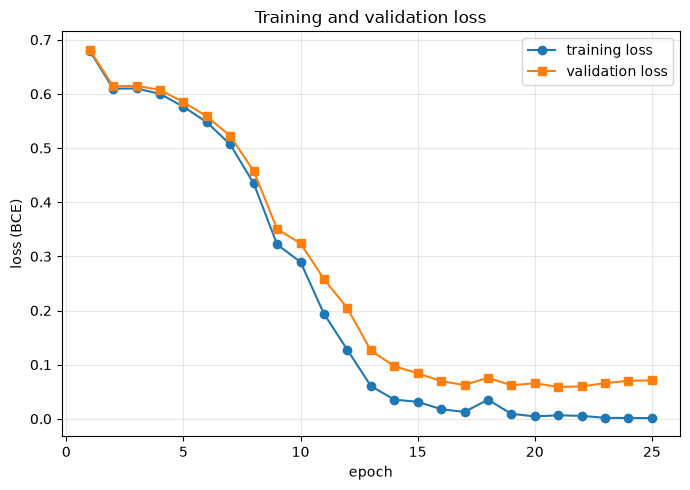

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history["epoch"], history["train_loss"], "o-", lw=1.5, label="training loss")
ax.plot(history["epoch"], history["val_loss"], "s-", lw=1.5, label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (BCE)")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
print("> saved loss_curve.png")

# Plot some results

> saved classification_examples.png
saved polymer_model.pt


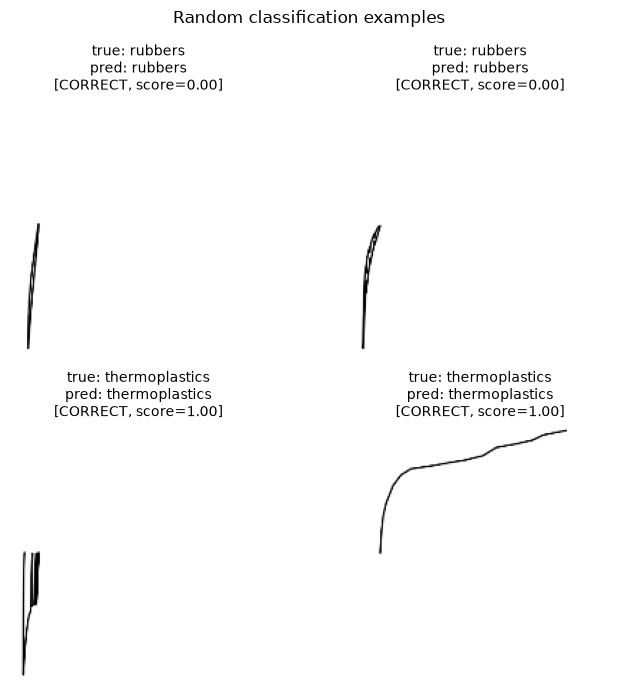

In [18]:
model.eval()
rng = torch.Generator().manual_seed(7)
ex_idxs = torch.randperm(len(val_ds), generator=rng)[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for ax, i in zip(axes.ravel(), ex_idxs):
    img_t, lbl = val_ds[i]
    with torch.no_grad():
        logit = model(img_t.unsqueeze(0).to(device))
    score = float(torch.sigmoid(logit))
    pred = 1 if score > 0.5 else 0
    correct = "CORRECT" if pred == lbl else "WRONG"
    ax.imshow(img_t.squeeze(0).numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"true: {CLASS_NAMES[lbl]}\npred: {CLASS_NAMES[pred]}\n[{correct}, score={score:.2f}]",
                 fontsize=10)
    ax.axis("off")
fig.suptitle("Random classification examples")
fig.tight_layout()

print("> saved classification_examples.png")
print("saved polymer_model.pt")
